In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from DataLoader import DataLoader, load_processed_data
import datetime
import random
import warnings
from BehaviourFeatureExtractor import BehaviourFeatureExtractor, convert_seconds_to_frame
from VocalFeatureExtractor import VocalFeatureExtractor
from colour import Color
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import sys
import cv2
import pprint

## Data Loading ##

Recursively finds video paths using DataLoader.

The notebook assumes the following paths:
-  that processed data can be accessed in `annotated_cleaned_resolved_data/`.
-  that raw data (including trial videos) can be found in `/data`.
-  that the annotated plots can be found in `plots/full_cleaned_resolved_annotation_plots/`.

These paths can be changed following the directory structure.

Exported video snippets of annotated trials (color shaded) will be exported to `annotated_video_snippets/`.

In [2]:
# data loader initialization
path_to_config_file = "config.json"
data_dir = "data/"
DL = DataLoader(data_dir=data_dir, path_to_config_file=path_to_config_file)

# directories
annotated_data_dir = "annotated_cleaned_resolved_data/"
annotated_plots_dir = "plots/full_cleaned_resolved_annotation_plots/"
export_video_snippet_dir = "annotated_video_snippets/"

# get mouse IDs and days
mouse_ids = [mouse_id for mouse_id in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, mouse_id))]
print("Mouse IDs:", mouse_ids)
days = [f"d{i}" for i in range(1, 7)]
print("Days:", days)

Found a directory at path data/
Found a directory at path data/MBQ0231R
Found a directory at path data/MBQ0231R/MBQ0231R_240217_d6
data/MBQ0231R/MBQ0231R_240217_d6/MBQ0231R_240217_d6_Avisoft/T0000001 2024-06-10  2_22 PM_Stats_SYNCCORRECTED.xlsx
Found a directory at path data/MBQ0231R/MBQ0231R_240217_d6
Found a directory at path data/MBQ0231R
Found a directory at path data/MBQ0231R/MBQ0231R_240212_d1
data/MBQ0231R/MBQ0231R_240212_d1/MBQ0231R_240212_d1_Avisoft/T0000001 2024-06-04  6_03 PM_Stats_SYNCCORRECTED.xlsx
Found a directory at path data/MBQ0231R/MBQ0231R_240212_d1
Found a directory at path data/MBQ0231R
Found a directory at path data/MBQ0231R/MBQ0231R_240215_d4
Found a directory at path data/MBQ0231R/MBQ0231R_240215_d4
data/MBQ0231R/MBQ0231R_240215_d4/MBQ0231R_240215_d4_Avisoft/T0000001 2024-06-06  5_41 2 PM_Stats_SYNCCORRECTED.xlsx
Found a directory at path data/MBQ0231R
Found a directory at path data/MBQ0231R/MBQ0231R_240214_d3
Found a directory at path data/MBQ0231R/MBQ0231R_24

The `DataLoader` loads dictionary of video paths (indexed by `mouse_id` and `day`) for all available videos in the raw data directory (`/data`)

`load_processed_data` loads processed data (containing behavioral labels in column `behavior_annotation`) for all trials that were successfully processed.

In [3]:
processed_and_annotated_data = load_processed_data(annotated_data_dir, mouse_ids, days)
video_dict = DL.video_dict.copy()

## Video annotation functions ##

The following functions are used for extracting, annotating and exporting videos of processed trials.

In [4]:
def apply_behavior_shading(video_array,                        
                           config,
                           trial_df,
                           behavior_col="behavior_annotation",
                           alpha=0.3):
    """
    Applies colored shading to video frames based on detected behaviors
    
    Args:
        video_array: numpy array of shape (frames, height, width, channels)
        behavior_window: pandas DataFrame containing behavior labels for each frame
        pickup_frame_index: frame index where pickup occurs
        alpha: transparency of the shading (0-1)
        pickup_window_size: number of frames before/after pickup to highlight
        
    Returns:
        numpy array with same shape as video_array but with behavior shading applied
    """
    dict_colors = {config["Behavioral_states"]["approach"]: "green",
                    config["Behavioral_states"]["crouching"]: "red",
                    config["Behavioral_states"]["active_interaction"]: "dodgerblue",
                    config["Behavioral_states"]["pickup"]: "magenta",
                    config["Behavioral_states"]["drop"]: "crimson",
                    config["Behavioral_states"]["carrying"]: "darkorange",
                    config["Behavioral_states"]["retrieval"]: "lime",
                    config["Behavioral_states"]["walking"]: "yellow",
                    config["Behavioral_states"]["still"]: "gray",
                    config["Behavioral_states"]["in_nest"]: "cyan"}

    # Create a copy to avoid modifying original
    shaded_video = video_array.copy()
    
    # Color mapping for behaviors (BGR format for OpenCV)
    color_map = {behavior: tuple(int(c*255) for c in Color(color).get_rgb()[::-1]) 
                 for behavior, color in dict_colors.items()}
    
    print("Color map for behaviors:")
    pprint.pprint(color_map)
        
    # iterate over each frame in trial_df, and apply shading if behavior is in color_map
    for frame_idx in range(len(trial_df)):
        behavior = trial_df[behavior_col].iloc[frame_idx]
        if behavior in color_map:
            overlay = shaded_video[frame_idx].copy()
            overlay = cv2.addWeighted(
                overlay,
                1-alpha,
                np.full_like(overlay, color_map[behavior]),
                alpha,
                0
            )
            shaded_video[frame_idx] = overlay

    return shaded_video

def create_annotated_video_segment(
                       video_path, trial_df, 
                       export_video_snippet_dir,
                       mouse_id, day, trial_num,
                       config):
    """
    Load a segment of a video file between start_frame and end_frame (frame indices).
    Parameters:
    video_path (str): Path to the video file.
    trial_df (pd.DataFrame): DataFrame containing trial data with frame indices.
    export_video_snippet_dir (str): Directory to save the video snippet.
    mouse_id (str): Mouse identifier.
    day (str): Day identifier.
    trial_num (int): Trial number.
    config (dict): Configuration dictionary loaded from config.json.
 
    Returns:
    tuple: (video_array, fps) where video_array is a numpy array of the video segment and fps is the frame rate.
    """

    frame_index_column=config["DLC_columns"]["frame"]
    frames_to_offset=config["frame_index_to_drop"]

    # determine start and end frames from trial_df
    start_frame = trial_df[frame_index_column].min()
    end_frame = trial_df[frame_index_column].max() + 1

    # offset both by frames_to_offset
    start_frame += frames_to_offset
    end_frame += frames_to_offset

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Skip frames before start_frame
    for _ in range(start_frame):
        ret = cap.grab()
        if not ret:
            break
    
    n_frames = end_frame - start_frame
    
    # Read first frame in segment to get dimensions
    ret, frame = cap.read()
    if not ret:
        cap.release()
        raise ValueError("Could not read start frame.")
    height, width, channels = frame.shape

    print(f"Video segment dimensions: {width}x{height}, Channels: {channels}, FPS: {fps}, Total frames: {n_frames}")
    print("Reading video frames...")
    video_array = np.empty((n_frames, height, width, channels), dtype=np.uint8)
    video_array[0] = frame
    
    frame_idx = 1
    while frame_idx < n_frames:
        ret, frame = cap.read()
        if not ret:
            break
        video_array[frame_idx] = frame
        frame_idx += 1
    
    cap.release()

    # Apply behavior shading to video frames
    print("Applying behavior shading to video frames...")
    shaded_video = apply_behavior_shading(video_array, config, trial_df)

    # save video segment as mp4 to output_directory
    print("Saving annotated video segment...")
    output_dir = os.path.join(export_video_snippet_dir, mouse_id, day)
    os.makedirs(output_dir, exist_ok=True)
    
    output_path = os.path.join(output_dir, f"{mouse_id}_{day}_trial_{trial_num}_frame_{start_frame}_to_{end_frame}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    for i in range(n_frames):
        out.write(shaded_video[i])

    out.release()

    return shaded_video, fps

## Running the video annotation for one trial ##

Select a trial by `mouse_id`, `day` and `trial_num`.

In [5]:
mouse_id = 'VAC0143LLR'
day = 'd1'
trial_num = 7

# another example
# mouse_id = 'MBI5335RR'
# day = 'd1'
# trial_num = 2

Run the following to extract the processed trial dataframe and to find the corresponding path to the video.

This cell should show the printed video path and the corresponding trial dataframe for the trial.

Video path:
 data/VAC0143LLR/VAC0143LLR_221110_d1/VAC0143LLR_d1DLC_resnet50_behav_trajectories_Oct2024Oct24shuffle1_100000_filtered_labeled.mp4

Trial df:


,frame_index,time_seconds,nose_x,nose_y,nose_likelihood,earRight_x,earRight_y,earRight_likelihood,earLeft_x,earLeft_y,...,approach,crouching,active_interaction,walking,still,pickup,drop,carrying,retrieval,behavior_annotation
0,40697,1356.566667,210.943253,66.150497,0.104921,192.032806,61.383057,0.617639,198.132965,57.267467,...,False,False,False,False,False,False,False,False,False,in_nest
1,40698,1356.600000,211.013275,65.985619,0.106712,191.803619,61.224346,0.638139,197.903381,57.125175,...,False,False,False,False,False,False,False,False,False,in_nest
2,40699,1356.633333,210.942062,66.356369,0.109179,191.175064,61.487766,0.667245,197.277252,57.344223,...,False,False,False,False,False,False,False,False,False,in_nest
3,40700,1356.666667,210.807205,66.157120,0.084672,191.061142,62.343567,0.606050,197.124756,57.600563,...,False,False,False,False,False,False,False,False,False,in_nest
4,40701,1356.700000,211.239914,65.773239,0.108967,191.349976,62.107445,0.641633,197.613129,57.210667,...,False,False,False,False,False,False,False,False,False,in_nest


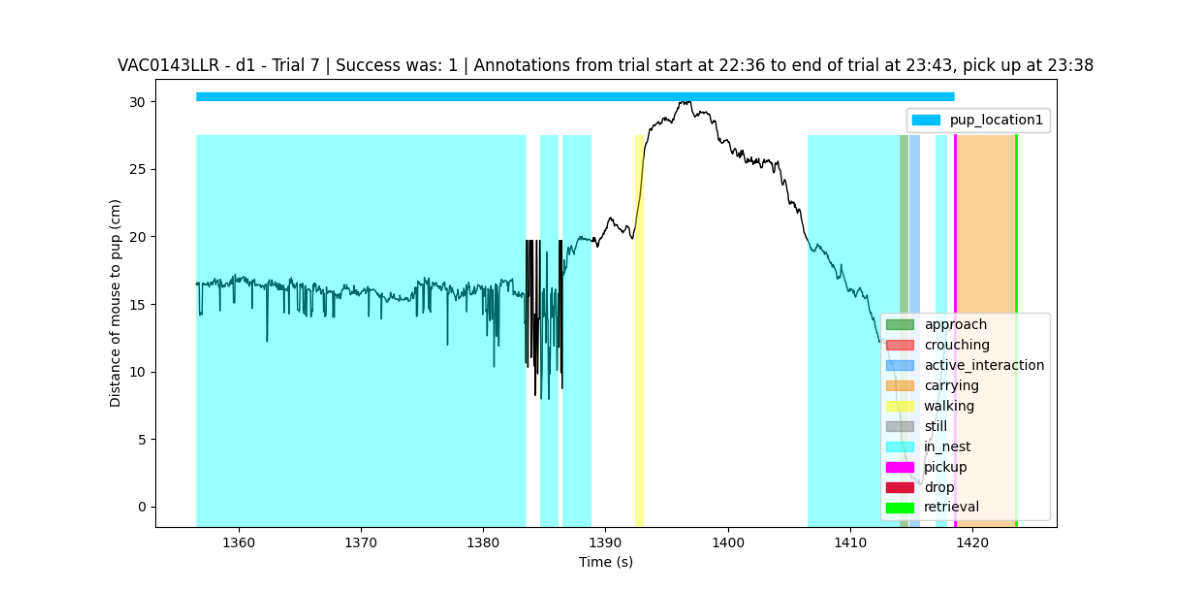

In [6]:
# selects the trial dataframe and video path for the specified trial
trial_df = processed_and_annotated_data[mouse_id][day]["trials"][trial_num]["dlc_data"]
trial_video_path = video_dict[mouse_id][day]

# see video path and trial df
print(f"Video path:\n {trial_video_path}")
print(f"\nTrial df:")
display(trial_df.head())

# see the plot
path_to_annotated_plot = os.path.join(annotated_plots_dir,
                                      mouse_id, day,
                                      f"{mouse_id}_{day}_trial_{trial_num}.png")
img = plt.imread(path_to_annotated_plot)
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

Run the following to export an annotated video segment for the selected trial.

A directory `/mouse_id/day` will be added to the `annotated_video_snippets/` directory, where you can find the output video.

In [7]:
config = DL.config
video_array, _ = create_annotated_video_segment(trial_video_path, trial_df, 
                       export_video_snippet_dir,
                       mouse_id, day, trial_num, config)

Video segment dimensions: 640x480, Channels: 3, FPS: 29.94, Total frames: 2010
Reading video frames...
Applying behavior shading to video frames...
Color map for behaviors:
{'active_interaction': (255, 144, 30),
 'approach': (0, 128, 0),
 'carrying': (0, 140, 255),
 'crouching': (0, 0, 255),
 'drop': (59, 19, 220),
 'in_nest': (255, 254, 0),
 'pickup': (254, 0, 255),
 'retrieval': (0, 255, 0),
 'still': (128, 128, 128),
 'walking': (0, 254, 255)}
Saving annotated video segment...
